# Compare Human Ratings vs. Abstract Similarity

For each author, human ratings (VAS 0–100) are **z-score standardised per author**. Abstract similarity values are read directly from the **globally z-scored matrix** (normalised across all 9,870 off-diagonal pairs in `abstract_similarity.ipynb`) — no re-standardisation on the per-author subsample. The two series are then correlated with **Pearson r** and **Spearman ρ**.


In [1]:
import json
import os

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE_DIR   = os.path.dirname(os.path.abspath("compare_ratings.ipynb"))
DATA_DIR   = os.path.join(BASE_DIR, '..', 'datasets')

RATINGS_FILE     = os.path.join(BASE_DIR, 'ratings_abstract.json')
ASSIGNMENTS_FILE = os.path.join(BASE_DIR, 'pair_assignments.json')
ABS_SIM_FILE     = os.path.join(DATA_DIR, 'abstract_similarity', 'normalized_abstract_similarity.csv')


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────────
with open(RATINGS_FILE) as f:
    all_ratings = json.load(f)

with open(ASSIGNMENTS_FILE) as f:
    assignments = json.load(f)

# Abstract similarity matrix (raw cosine similarities, diagonal = NaN)
abs_sim = pd.read_csv(ABS_SIM_FILE, index_col=0)
abs_sim.columns = abs_sim.columns.astype(int)
abs_sim.index   = abs_sim.index.astype(int)

print(f"Authors with submitted ratings : {list(all_ratings.keys())}")
print(f"Similarity matrix shape        : {abs_sim.shape}")


Authors with submitted ratings : ['Jonas']
Similarity matrix shape        : (141, 141)


In [3]:
def standard_normalize(values: np.ndarray) -> np.ndarray:
    """Z-score normalisation (same formula as abstract_similarity.ipynb).
    Operates on a plain 1-D array; ignores NaN values when computing stats.
    """
    mean_val = np.nanmean(values)
    std_val  = np.nanstd(values)
    if std_val == 0:
        return values.copy()
    return (values - mean_val) / std_val


In [4]:
# ── Per-author correlation ─────────────────────────────────────────────────────
results = []

for author, data in all_ratings.items():
    rated_entries = {r['pair_index']: r for r in data['ratings']}
    author_pairs  = assignments['abstract'][author]  # list of [paper_a, paper_b]

    human_raw  = []
    absim_vals = []

    for pair_idx, pair in enumerate(author_pairs):
        if pair_idx not in rated_entries:
            continue                             # skip if somehow missing
        pa, pb = int(pair[0]), int(pair[1])
        sim_val = abs_sim.at[pa, pb]
        if np.isnan(sim_val):
            continue
        human_raw.append(rated_entries[pair_idx]['rating'])
        absim_vals.append(sim_val)

    if len(human_raw) < 3:
        print(f"{author}: not enough data to correlate ({len(human_raw)} pairs).")
        continue

    # Human ratings are z-scored per author (no pre-computed global reference).
    # Similarity values come pre-standardised from the global matrix — no re-normalisation.
    human_z  = standard_normalize(np.array(human_raw,  dtype=float))
    absim_z  = np.array(absim_vals, dtype=float)

    pearson_r, pearson_p  = stats.pearsonr(human_z, absim_z)
    spearman_r, spearman_p = stats.spearmanr(human_z, absim_z)

    results.append({
        'author':         author,
        'n_pairs':        len(human_raw),
        'pearson_r':      round(pearson_r,  4),
        'pearson_p':      round(pearson_p,  4),
        'spearman_rho':   round(spearman_r, 4),
        'spearman_p':     round(spearman_p, 4),
        # store arrays for plotting
        '_human_z':  human_z,
        '_absim_z':  absim_z,
    })

results_df = pd.DataFrame(results).drop(columns=['_human_z', '_absim_z'])
results_df


,author,n_pairs,pearson_r,pearson_p,spearman_rho,spearman_p
0,Jonas,25,0.4254,0.034,0.395,0.0507


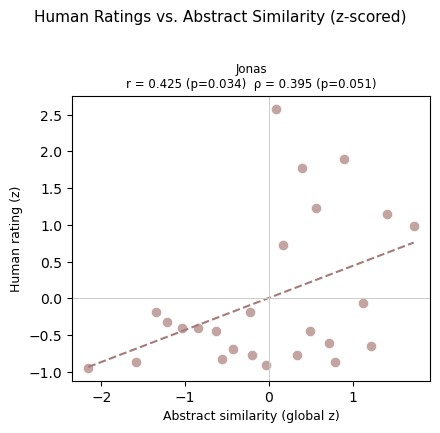

In [5]:
# ── Scatter plots: one per author ─────────────────────────────────────────────
n_authors = len(results)
if n_authors == 0:
    print("No results to plot yet.")
else:
    fig, axes = plt.subplots(1, n_authors, figsize=(4.5 * n_authors, 4.2), squeeze=False)

    for ax, row in zip(axes[0], results):
        hz = row['_human_z']
        az = row['_absim_z']

        ax.scatter(az, hz, color='#b89491', edgecolors='white', linewidths=0.5,
                   s=55, alpha=0.85)

        # regression line
        m, b = np.polyfit(az, hz, 1)
        x_line = np.linspace(az.min(), az.max(), 100)
        ax.plot(x_line, m * x_line + b, color='#a37c79', linewidth=1.5, linestyle='--')

        ax.set_xlabel('Abstract similarity (global z)', fontsize=9)
        ax.set_ylabel('Human rating (z)',               fontsize=9)
        ax.set_title(
            f"{row['author'].replace('_', ' ').title()}\n"
            f"r = {row['pearson_r']:.3f} (p={row['pearson_p']:.3f})  "
            f"ρ = {row['spearman_rho']:.3f} (p={row['spearman_p']:.3f})",
            fontsize=8.5
        )
        ax.axhline(0, color='#ccc', linewidth=0.7)
        ax.axvline(0, color='#ccc', linewidth=0.7)

    plt.suptitle('Human Ratings vs. Abstract Similarity (z-scored)', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
